# Libraries

Before run this notebook you need install the dependencies. See the `requirements.txt` file.


In [25]:
from functions_victor_project import *

import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import pickle
import dill
from scipy.integrate import odeint
from UQpy.distributions import Uniform, Normal, JointIndependent #, Lognormal
from UQpy.distributions.collection.Lognormal import Lognormal
from UQpy.surrogates import *
from sklearn.metrics import mean_squared_error, r2_score

# Statistics of the input variables

- $R$: Resistance variable  
- $S$: Demand variable  
- $Z_1$ and $Z_2$: Latent variables  

State Limit Function:

$$
g(R, S, t) = \frac{R}{Z_1} - S \cdot Z_2
$$

**Table 1:** Moments, distributions, and parameters of the considered variables for the $R$ and $S$ problem.

| Variable | Distribution | Mean | Std. Deviation |  
|----------|--------------|------|----------------|  
| $R$    | Normal     | 5.0  | 0.8            |  
| $S$    | Normal     | 2.0  | 0.6            |  
| $Z_1$ | Lognormal   | 1.0  | 0.028          |  
| $Z_2$ | Lognormal   | 1.0  | 0.096          |  

To simulate $Z_1$ and $Z_2$ we are used `scipy` library. You can see the file `glam_example_1.py` and how to generate state limit results. 

### Transformation to scipy parameters

**Shape parameter (s):**
$$
s = \sqrt{\ln\left(1 + \left(\frac{\sigma}{\mu}\right)^2\right)}
$$

**Scale parameter:**
$$
\text{scale} = \frac{\mu}{\sqrt{1 + \left(\frac{\sigma}{\mu}\right)^2}}
$$

Where:
- $\mu$ = mean of the lognormal distribution  
- $\sigma$ = standard deviation of the lognormal distribution
- $s$ = shape parameter for `scipy.stats.lognorm`
- $\text{scale}$ = scale parameter for `scipy.stats.lognorm`

# Samples

We use $n_{samples}$ as number of samples and $n_{latent,samples}$ stands a number of latent samples.

In [26]:
n_samples = 1000
n_latent_samples = 2000

### Generating samples

In [27]:
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x = joint.rvs(n_samples)
x

array([[5.22430089, 1.45203446],
       [4.89261022, 2.26953717],
       [4.82295188, 3.01207886],
       ...,
       [5.35624341, 1.71556503],
       [5.67598975, 0.80356505],
       [4.38784311, 3.29188649]])

### Computing output values

In [28]:
y, _ = state_limit_function(x, n_latent_samples)
y

array([[3.77985026, 7.06283038, 0.11717716, 0.14607743],
       [2.62531455, 5.60945496, 0.08143063, 0.15193962],
       [1.82290708, 4.63991449, 0.12814544, 0.2048626 ],
       ...,
       [3.640921  , 6.30837004, 0.17257651, 0.19075802],
       [4.87579583, 8.1019303 , 0.14526022, 0.15466911],
       [1.12250464, 4.53174878, 0.079803  , 0.16521916]])

# Training with PCE

### Check dimensions

In [29]:
print("xx shape:", x.shape)
print("yy shape:", y.shape)

xx shape: (1000, 2)
yy shape: (1000, 4)


### Train

Using PCE with 4 degrees and Least Square Regression to fit a hyperparameters.

In [30]:
max_degree = 3

In [31]:
polynomial_basis = TotalDegreeBasis(joint, max_degree)
least_squares = LeastSquareRegression()
pce_metamodel = PolynomialChaosExpansion(polynomial_basis=polynomial_basis, regression_method=least_squares)
pce_metamodel.fit(x, y)
with open('pce_metamodel.pkl', 'wb') as f:
    dill.dump(pce_metamodel, f)

### Coefficients

In [32]:
# pce_metamodel.coefficients
a = pce_metamodel.polynomial_basis.evaluate_basis(np.array([[5.0, 2.0]]))
a

array([[ 1.        ,  0.        ,  0.        , -0.70710678,  0.        ,
        -0.70710678, -0.        , -0.        , -0.        , -0.        ]])

In [33]:
c = pce_metamodel.coefficients
c

array([[ 3.01061411e+00,  6.35313593e+00,  1.09905518e-01,
         1.57836248e-01],
       [ 7.99681141e-01, -4.13526605e-01,  5.08393260e-03,
        -5.36204355e-03],
       [-5.95992656e-01, -1.21720416e+00, -1.11659076e-02,
         1.08593436e-02],
       [ 6.17033761e-04,  2.00256260e-01,  2.21514605e-03,
        -1.12910194e-03],
       [ 3.38157641e-04,  2.34919065e-01, -5.93960561e-04,
         1.21699502e-03],
       [ 2.43832318e-04,  2.80171993e-02, -7.67412014e-04,
        -3.44531854e-04],
       [ 6.05866859e-05,  3.65606500e-02, -1.06660692e-03,
        -1.91438782e-03],
       [ 5.01731949e-04, -9.04082055e-02, -1.62253810e-03,
         5.93313388e-04],
       [-3.79088668e-05, -3.16919537e-02,  5.91533315e-04,
        -9.14483560e-04],
       [-1.32366992e-04, -1.33748473e-02,  1.32345020e-03,
         6.74713644e-04]])

In [34]:
y = a.dot(c)
y

array([[3.01000538, 6.19172222, 0.10888182, 0.15887826]])

### Validation

In [35]:
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x_val = joint.rvs(n_samples)
y_val_obs, final_df = state_limit_function(x_val, n_latent_samples)

In [36]:
y_val_obs[0, :]

array([3.43126839, 5.95475862, 0.12298777, 0.14480681])

### Check dataframe format and one sample of state limit function

Here I check the format of one sample of the $R$ and $S$ variables. I used the KDE histogram plot. In this case I checked `0` row.

In [37]:
final_df[0].head()

,r,s,z1,z2,g
0,5.476125,2.04709,0.996280,1.076721,3.292425
1,5.476125,2.04709,0.966940,0.932123,3.755219
2,5.476125,2.04709,0.973200,0.993765,3.592601
3,5.476125,2.04709,1.005860,0.934383,3.531456
4,5.476125,2.04709,1.016456,1.091061,3.153968


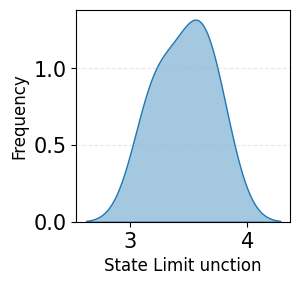

In [38]:
data = final_df[0].head()
ratio_data = data['g']

# Figure Size in Centimeters
width_cm = 7
height_cm = 7
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

y_axis_label = 'State Limit unction'
label_size = 12
label_color = 'black'

# KDE Plot
plt.figure(figsize=(width_in, height_in))
sns.kdeplot(data=ratio_data, fill=True, alpha=0.4)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel(y_axis_label, fontsize=label_size, color=label_color)
plt.ylabel('Frequency', fontsize=label_size, color=label_color)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()
# plt.savefig('state_limit_funciton_histogram_one_sample.png', dpi=600)

### Evaluation x_val using PCE model

In [39]:
y_val_pre = pce_metamodel.predict(x_val)

In [40]:
y_val_pre[0, :]

array([3.43911587, 5.91298168, 0.11072987, 0.15603944])

In [41]:
test_lambda_values = list(y_val_pre[0, :])
test_lambda_values

[3.439115866461186, 5.912981675315989, 0.1107298653372582, 0.15603943519469482]

### Scatter plot

#### Dataset of first moment of GLAM

In [42]:
y_val_obs_aux = list(y_val_obs[:, 0])
y_val_pre_aux = list(y_val_pre[:, 0])                 

#### Scatter image

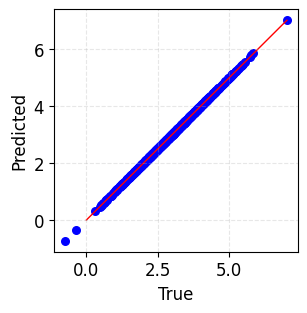

In [43]:
# Figure dimension
width_cm = 8
height_cm = 8
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

# Labels properties
label_x = 'True'
label_y = 'Predicted'
label_size = 12
axis_size = 12
label_color = 'black'

# Scatter Plot
point_size = 30
color_scatter = 'blue'
plt.figure(figsize=(width_in, height_in))
plt.scatter(y_val_obs_aux, y_val_pre_aux,
            s=point_size,
            c=color_scatter)

# Regression Line
regression_line_color = 'red'
regression_line_style = '-'
regression_line_width = 1
x_line = np.array([0, max(y_val_obs_aux)])
y_line = x_line
plt.plot(x_line, y_line,
         color=regression_line_color,
         linestyle=regression_line_style,
         linewidth=regression_line_width,
         zorder=1)

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel(label_x, fontsize=label_size, color=label_color)
plt.ylabel(label_y, fontsize=label_size, color=label_color)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()
# plt.savefig('validation_scatter_train.png', dpi=600)

### All $\lambda$ GLAM parameters

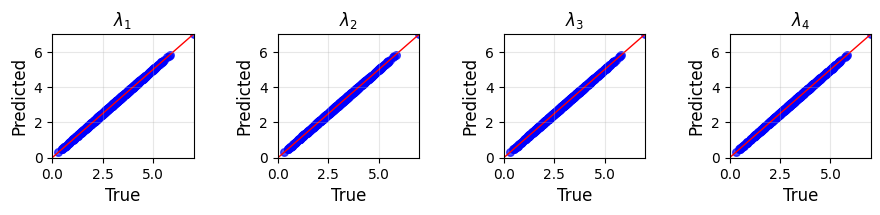

In [44]:
# Data for the 4 charts (replace with your actual data)
y_val_obs_aux1 = list(y_val_obs[:, 0])
y_val_pre_aux1 = list(y_val_pre[:, 0])    
y_val_obs_aux2 = list(y_val_obs[:, 0])
y_val_pre_aux2 = list(y_val_pre[:, 0])   
y_val_obs_aux3 = list(y_val_obs[:, 0])
y_val_pre_aux3 = list(y_val_pre[:, 0])   
y_val_obs_aux4 = list(y_val_obs[:, 0])
y_val_pre_aux4 = list(y_val_pre[:, 0])   
datasets = [
    (y_val_obs_aux1, y_val_pre_aux1, '$\lambda _1$'),
    (y_val_obs_aux2, y_val_pre_aux2, '$\lambda _2$'),
    (y_val_obs_aux3, y_val_pre_aux3, '$\lambda _3$'),
    (y_val_obs_aux4, y_val_pre_aux4, '$\lambda _4$'),
]

# Figure dimensions for 4 charts in a row
width_cm_per_chart = 6
height_cm = 6
inches_per_cm = 1 / 2.54
width_in_total = width_cm_per_chart * 4 * inches_per_cm  # Total width for 4 charts
height_in = height_cm * inches_per_cm

# Labels properties
label_x = 'True'
label_y = 'Predicted'
label_size = 12
axis_size = 10
label_color = 'black'

# Scatter plot settings
point_size = 30
color_scatter = 'blue'

# Regression line settings
regression_line_color = 'red'
regression_line_style = '-'
regression_line_width = 1

# Create figure with subplots
fig, axes = plt.subplots(1, 4, figsize=(width_in_total, height_in))
fig.tight_layout(pad=3.0)  # Add padding between subplots

# Plot each dataset in its own subplot
for i, (y_obs, y_pred, title) in enumerate(datasets):
    ax = axes[i]
    
    # Scatter plot
    ax.scatter(y_obs, y_pred,
               s=point_size,
               c=color_scatter,
               alpha=0.7)
    
    # Regression line (y = x)
    x_line = np.array([0, max(y_obs)])
    y_line = x_line
    ax.plot(x_line, y_line,
            color=regression_line_color,
            linestyle=regression_line_style,
            linewidth=regression_line_width,
            zorder=1)
    
    # Customize each subplot
    ax.tick_params(axis='both', which='major', labelsize=axis_size)
    ax.set_xlabel(label_x, fontsize=label_size, color=label_color)
    ax.set_ylabel(label_y, fontsize=label_size, color=label_color)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=label_size)
    
    # Set consistent axis limits for better comparison
    max_val = max(max(y_obs), max(y_pred))
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)

plt.show()
# plt.savefig('validation_scatter_train_all_lambdas.png', dpi=600)

#### Scores

In [45]:
print("R2:", r2_score(y_val_obs_aux, y_val_pre_aux))
print("MSE:", mean_squared_error(y_val_obs_aux, y_val_pre_aux))

R2: 0.9999631339565772
MSE: 3.7372051778352684e-05


#### Compare g state limit function and GLAM emulator

In [46]:
def plot_gld_vs_data(lambdas, n_points=5000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas

    # Curva da PDF GLD (robusta para evitar explosões numéricas)
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0 / qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    return list(x), list(f)

glam_data, _ = plot_gld_vs_data(test_lambda_values) 

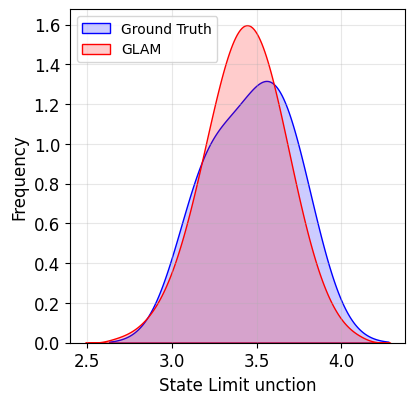

In [47]:
# Figure dimension ans properties
width_cm = 11
height_cm = 11
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm
label_size = 12
axis_size = 12
legend_size = 10
label_color = 'black'

# Plot first KDE with specific color
plt.figure(figsize=(width_in, height_in))

# Ground Truth
sns.kdeplot(data=ratio_data, fill=True, alpha=0.2, color='blue', label='Ground Truth')

# GLAM
sns.kdeplot(data=glam_data, fill=True, alpha=0.2, color='red', label='GLAM')

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel(y_axis_label, fontsize=label_size, color=label_color)
plt.ylabel('Frequency', fontsize=label_size, color=label_color)
plt.grid(alpha=0.3)
plt.legend(fontsize=legend_size, loc='upper left')
plt.show()
# plt.savefig('compare_GLAM_and_GROUNDTRUTH.png', dpi=600)

### Load model usign pickle

In [48]:
import pickle
with open('pce_metamodel.pkl', 'rb') as f:
    pce_metamodel = pickle.load(f)